# Model Primer v3 — Corrected Masks (ResNet-34 Encoder U-Net)

Same architecture and recipe as `model_primer_v3`, retrained on the
**colleague-corrected** v2 dataset (`Scoliosis_Dataset_v2_corrected/`).
Trainable pool jumps from 152 → 249 cases (full T1..L5 coverage on 147
previously-incomplete masks)

Checkpoints are saved per-config under
`ai/models/checkpoints/v3_corrected/<timestamp>_<hash>/` and reloaded on
rerun when the config hash matches.


## 0 · Setup

In [3]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from PIL import Image
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore", message=".*lerp.*")

In [4]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [5]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.models.architectures.encoder_unet import EncoderUNet
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import augment_v4
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    SpineDataset,
    preprocess_case,
    read_gray,
    read_mask,
)
from ai.training.losses import seg_loss_fn

print(f"target_size={IMG_H}x{IMG_W}  classes={NUM_SEG_CLASSES}  target_ids={TARGET_IDS_V2[:3]}..{TARGET_IDS_V2[-1]}")

target_size=512x256  classes=18  target_ids=(1, 2, 3)..17


In [6]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)}  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249  train=199  val=50


In [7]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "v3_corrected"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

def build_run_config(extra: dict | None = None) -> dict:
    cfg = {
        "dataset": "v2_corrected",
        "encoder": ENCODER_NAME,
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER,
        "lr_decoder": LR_DECODER,
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE,
        "dropout": DROPOUT,
        "seed": SEED,
        "trainable_count": int(len(TRAINABLE)),
    }
    if extra:
        cfg.update(extra)
    return cfg

def config_hash(cfg: dict) -> str:
    payload = json.dumps(cfg, sort_keys=True, default=str).encode()
    return hashlib.sha256(payload).hexdigest()[:8]

def find_cached_run(cfg: dict, root: Path = CHECKPOINT_ROOT) -> Path | None:
    h = config_hash(cfg)
    for p in sorted(root.glob(f"*_{h}")):
        if (p / "model.pt").exists():
            return p
    return None

def new_run_dir(cfg: dict, root: Path = CHECKPOINT_ROOT) -> Path:
    stamp = datetime.now().strftime("%Y%m%dT%H%M")
    p = root / f"{stamp}_{config_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True)
    return p

def save_run(run_dir: Path, model: nn.Module, history_df: pd.DataFrame,
             cfg: dict, metrics: dict) -> None:
    torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()},
               run_dir / "model.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2, default=str))
    print(f"  saved -> {run_dir.relative_to(REPO_ROOT)}")

def load_run(run_dir: Path) -> tuple[dict, pd.DataFrame, dict]:
    state = torch.load(run_dir / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(run_dir / "history.csv")
    metrics = json.loads((run_dir / "metrics.json").read_text())
    print(f"  loaded cached run <- {run_dir.relative_to(REPO_ROOT)}")
    return state, history_df, metrics


## 1 · Input / Output Contract

Raw inputs from disk, derived supervision targets for both task families (segmentation and keypoints), and the tensor shapes the model will see.

In [8]:
def pick_sample(df: pd.DataFrame, status: str = "ok") -> pd.Series:
    return df[df["status"] == status].iloc[0]

sample = pick_sample(TRAINABLE, "ok")
case = preprocess_case(sample)
print(f"image  {tuple(case['image'].shape)} {case['image'].dtype}")
print(f"seg    {tuple(case['seg'].shape)} {case['seg'].dtype}  classes={sorted(torch.unique(case['seg']).tolist())}")
print(f"kps    {tuple(case['kps'].shape)} {case['kps'].dtype}  finite={int(torch.isfinite(case['kps']).all(dim=1).sum())}/68")

image  (1, 512, 256) torch.float32
seg    (512, 256) torch.int64  classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
kps    (68, 2) torch.float32  finite=68/68


**Contract (post-resize to 512×256):**

| Tensor | Shape | Dtype | Role |
|---|---|---|---|
| `image` | `(1, 512, 256)` | `float32` | grayscale radiograph, normalized to `[0, 1]` |
| `seg` | `(512, 256)` | `int64` | per-pixel class label, `0=bg, 1..17=T1..L5` |

## 2 · Preprocessing + Augmentation Pipeline

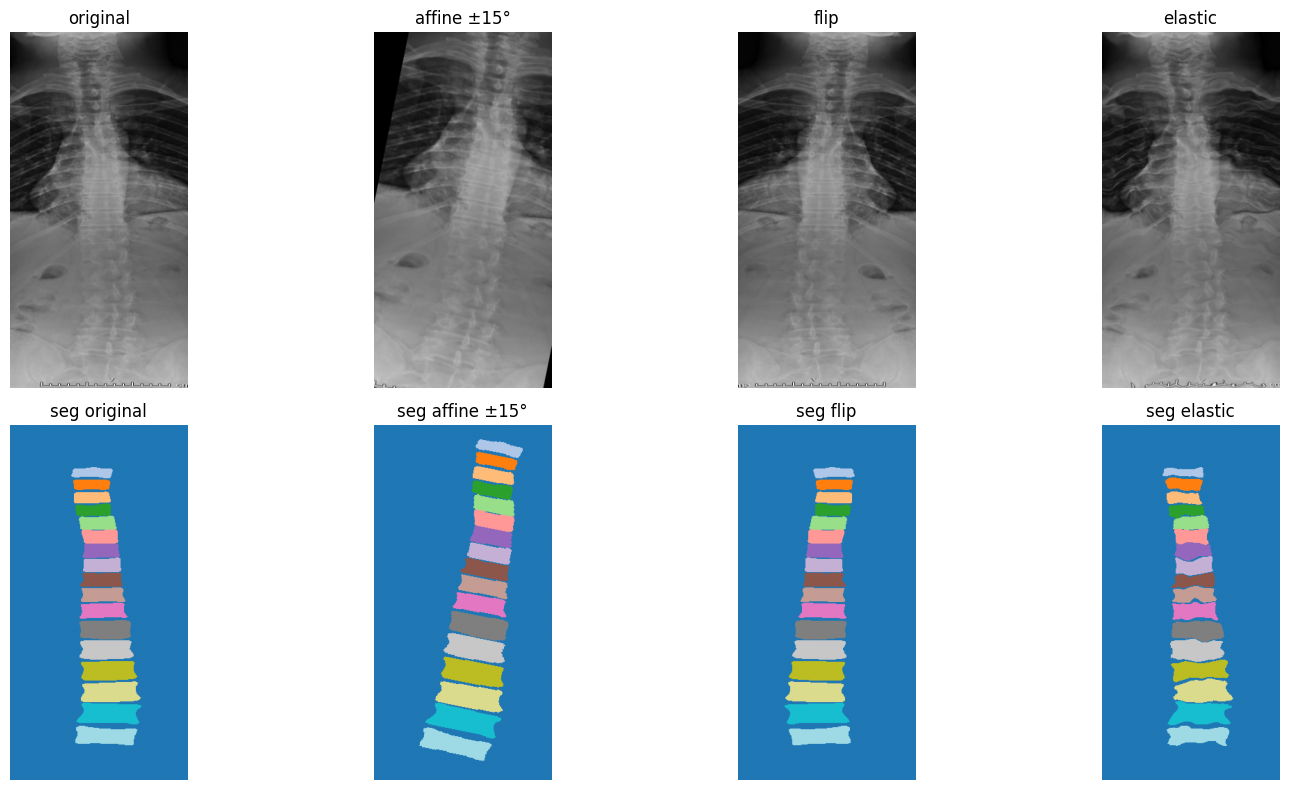

In [9]:
case = preprocess_case(TRAINABLE.iloc[0])
image, seg = case["image"], case["seg"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(image.squeeze(0), cmap="gray"); axes[0, 0].set_title("original")
axes[1, 0].imshow(seg, cmap="tab20"); axes[1, 0].set_title("seg original")

from ai.training.augmentation import (
    affine_transform, intensity_jitter, horizontal_flip,
    elastic_deform, gaussian_noise, gamma_correction,
)
transforms = [
    ("affine ±15°", lambda i, s: affine_transform(i, s, angle_range=(-15.0, 15.0), translate_frac=0.10, scale_range=(0.85, 1.15))),
    ("flip", lambda i, s: horizontal_flip(i, s)),
    ("elastic", lambda i, s: elastic_deform(i, s, alpha=40.0, sigma=6.0)),
]
for col, (name, fn) in enumerate(transforms, 1):
    aug_img, aug_seg = fn(image.clone(), seg.clone())
    axes[0, col].imshow(aug_img.squeeze(0), cmap="gray"); axes[0, col].set_title(name)
    axes[1, col].imshow(aug_seg, cmap="tab20"); axes[1, col].set_title(f"seg {name}")
for ax in axes.flat:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 3 · EncoderUNet Architecture

ResNet-34 (ImageNet pretrained) encoder + U-Net decoder. ~24M params, Dropout2d(0.2) in decoder.
Grayscale stem: pretrained RGB conv1 weights averaged → 1 channel.

In [10]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

ENCODER_NAME = "resnet34"
model = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True, dropout=0.2, encoder_name=ENCODER_NAME).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"EncoderUNet ({ENCODER_NAME}) total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder: {n_dec:,}")

EncoderUNet (resnet34) total params: 24,394,034
  encoder: 21,278,400  decoder: 3,115,634


Dropped Escape call with ulEscapeCode : 0x03007703


## 4 · Forward-Pass Sanity Check

In [11]:
def predict_one(model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        seg_logits = model(image.unsqueeze(0).to(DEVICE))
    return seg_logits.argmax(dim=1).squeeze(0).cpu()

case = preprocess_case(TRAINABLE.iloc[0])
seg_pred = predict_one(model, case["image"])
print(f"seg  shape={tuple(seg_pred.shape)} dtype={seg_pred.dtype} unique={sorted(torch.unique(seg_pred).tolist())[:6]}...")

seg  shape=(512, 256) dtype=torch.int64 unique=[4, 10, 14]...


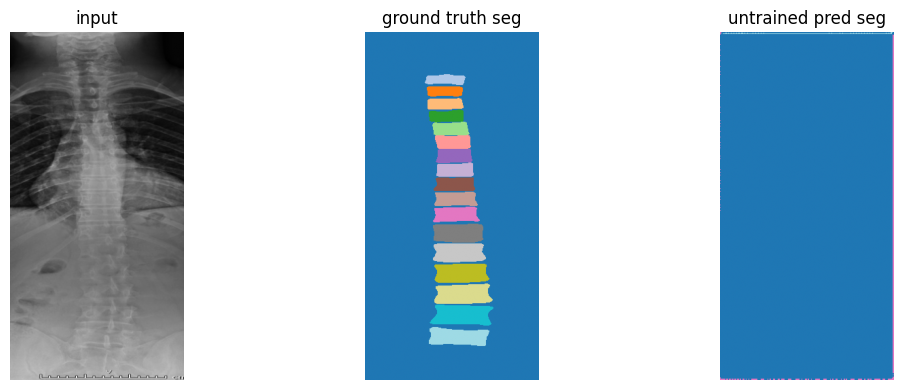

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input"); axes[0].set_axis_off()
axes[1].imshow(case["seg"], cmap="tab20");             axes[1].set_title("ground truth seg"); axes[1].set_axis_off()
axes[2].imshow(seg_pred, cmap="tab20");                axes[2].set_title("untrained pred seg"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()

## 5 · Training Loop

Differentiated LR: encoder 1e-4 (preserve pretrained features), decoder 1e-3 (learn from scratch).

**Config (baseline):**
- **ResNet-34 encoder** (~24M params) — train loss 1.46→0.26 while val loss plateaus at ~0.70 → overfit post-ep 40 without reg.
- **Dropout 0.2** · **weight decay 2e-4** · **patience 20** · **100 epochs max** — light regularization, full patience. Stronger reg (dropout 0.3, wd 5e-4, patience 10–15) regressed dice on single 30-case split → noise floor ~±0.05.
- **augment_v4** — ±15° rot, ±10% translate, elastic, gamma, blur, CLAHE, noise.
- **Smoothed tangent Cobb** — MAE 17.2° vs 19.7° polynomial at training resolution.
- **Encoder freeze warmup** (10 epochs), CosineAnnealingLR after unfreeze.
- **Tune further via 5-fold CV + Optuna**, not single-split sweeps.

In [13]:
def train_step(model: nn.Module,
               batch: tuple[torch.Tensor, torch.Tensor],
               optimizer: torch.optim.Optimizer) -> float:
    images, seg_t = [t.to(DEVICE) for t in batch]
    seg_logits = model(images)
    loss = seg_loss_fn(seg_logits, seg_t, NUM_SEG_CLASSES)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return float(loss.item())

def run_epoch(model: nn.Module, loader: DataLoader,
              optimizer: torch.optim.Optimizer) -> np.ndarray:
    model.train()
    return np.array([train_step(model, b, optimizer) for b in loader])

@torch.no_grad()
def validate(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card  = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    for batch in loader:
        images, seg_t = [t.to(DEVICE) for t in batch]
        seg_logits = model(images)
        total_loss += float(seg_loss_fn(seg_logits, seg_t, NUM_SEG_CLASSES))
        pred_mask = seg_logits.argmax(dim=1)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1]  += p.sum() + g.sum()
    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid = card > 0
    return {
        "loss": total_loss / max(1, len(loader)),
        "dice": float(dice_per_cls[valid].mean()) if valid.any() else float("nan"),
    }

In [14]:
NUM_EPOCHS = 100
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 20
DROPOUT = 0.2

cfg_single = build_run_config({"phase": "single_split", "val_frac": 0.2})
_cached = find_cached_run(cfg_single)

if _cached is not None:
    state, history_df, _metrics = load_run(_cached)
    model = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=False, dropout=DROPOUT, encoder_name=ENCODER_NAME).to(DEVICE)
    model.load_state_dict(state)
    best_dice = float(_metrics["best_val_dice"])
    print(f"reused cached single-split run, best val_dice={best_dice:.3f}")
else:
    model = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True, dropout=DROPOUT, encoder_name=ENCODER_NAME).to(DEVICE)
    print(f"EncoderUNet ({ENCODER_NAME}) params: {count_params(model):,}  dropout={DROPOUT}")
    
    train_loader = DataLoader(
        SpineDataset(TRAIN_DF, augment=True, augment_fn=augment_v4),
        batch_size=BATCH_SIZE, shuffle=True,
    )
    val_loader = DataLoader(
        SpineDataset(VAL_DF, augment=False),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    
    # Phase 1: freeze encoder, train decoder only
    for p in model.encoder_params():
        p.requires_grad = False
    
    optimizer = torch.optim.Adam(
        model.decoder_params(), lr=LR_DECODER, weight_decay=WEIGHT_DECAY
    )
    scheduler = None
    
    history: list[dict[str, float]] = []
    best_dice = -1.0
    best_state: dict[str, torch.Tensor] | None = None
    no_improve = 0
    
    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
    
        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params():
                p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER},
                {"params": model.decoder_params(), "lr": LR_DECODER},
            ], weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
            )
            print(f"  >>> encoder unfrozen at epoch {epoch}")
    
        train_losses = run_epoch(model, train_loader, optimizer)
        val_stats = validate(model, val_loader)
        if scheduler is not None:
            scheduler.step()
    
        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":      epoch,
            "train_loss": float(train_losses.mean()),
            "val_loss":   val_stats["loss"],
            "val_dice":   val_stats["dice"],
            "lr_enc":     float(optimizer.param_groups[0]["lr"]) if n_groups > 1 else 0.0,
            "lr_dec":     float(optimizer.param_groups[-1]["lr"]),
            "sec":        time.time() - t0,
        }
        history.append(row)
    
        if val_stats["dice"] > best_dice:
            best_dice = val_stats["dice"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
    
        tag = " *" if no_improve == 0 else ""
        print(f"epoch {epoch:3d}/{NUM_EPOCHS}  "
              f"train={row['train_loss']:.3f}  val={row['val_loss']:.3f}  "
              f"dice={row['val_dice']:.3f}  lr_e={row['lr_enc']:.1e}  lr_d={row['lr_dec']:.1e}  "
              f"({row['sec']:.1f}s){tag}")
    
        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    print(f"\ntotal time: {time.time() - t_start:.1f}s  best val_dice={best_dice:.3f}")
    save_run(new_run_dir(cfg_single), model, history_df, cfg_single,
             {"best_val_dice": best_dice, "stopped_epoch": int(history_df['epoch'].iloc[-1])})


EncoderUNet (resnet34) params: 24,394,034  dropout=0.2
epoch   1/100  train=1.390  val=1.573  dice=0.009  lr_e=0.0e+00  lr_d=1.0e-03  (12.7s) *
epoch   2/100  train=1.174  val=1.194  dice=0.066  lr_e=0.0e+00  lr_d=1.0e-03  (8.9s) *
epoch   3/100  train=1.074  val=1.124  dice=0.136  lr_e=0.0e+00  lr_d=1.0e-03  (8.8s) *
epoch   4/100  train=1.029  val=1.023  dice=0.156  lr_e=0.0e+00  lr_d=1.0e-03  (11.6s) *
epoch   5/100  train=1.022  val=1.012  dice=0.155  lr_e=0.0e+00  lr_d=1.0e-03  (8.7s)
epoch   6/100  train=0.990  val=0.994  dice=0.218  lr_e=0.0e+00  lr_d=1.0e-03  (8.6s) *
epoch   7/100  train=0.944  val=0.969  dice=0.195  lr_e=0.0e+00  lr_d=1.0e-03  (8.7s)
epoch   8/100  train=0.949  val=0.889  dice=0.323  lr_e=0.0e+00  lr_d=1.0e-03  (11.5s) *
epoch   9/100  train=0.927  val=0.899  dice=0.237  lr_e=0.0e+00  lr_d=1.0e-03  (8.5s)
epoch  10/100  train=0.916  val=0.857  dice=0.318  lr_e=0.0e+00  lr_d=1.0e-03  (8.6s)
  >>> encoder unfrozen at epoch 11
epoch  11/100  train=0.884  val=0.8

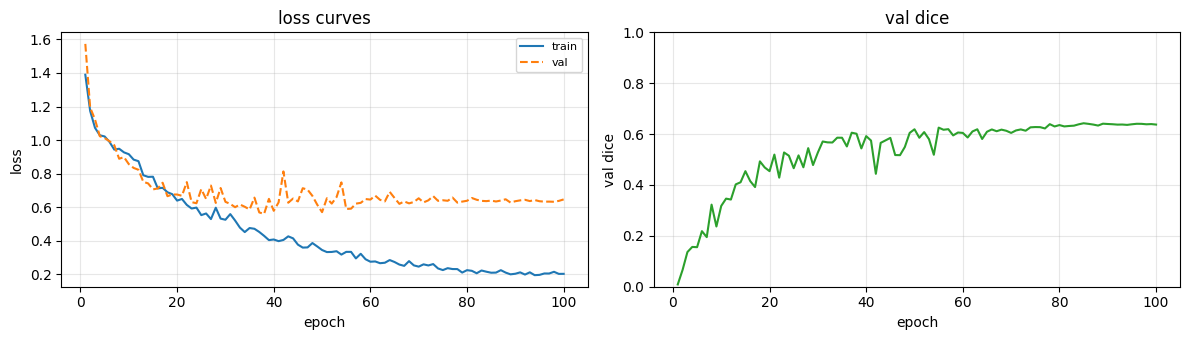

In [15]:
fig, (ax_loss, ax_dice) = plt.subplots(1, 2, figsize=(12, 3.5))

ax_loss.plot(history_df["epoch"], history_df["train_loss"], label="train", linewidth=1.5)
ax_loss.plot(history_df["epoch"], history_df["val_loss"],   label="val",   linewidth=1.5, linestyle="--")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("loss"); ax_loss.set_title("loss curves")
ax_loss.legend(fontsize=8); ax_loss.grid(alpha=0.3)

ax_dice.plot(history_df["epoch"], history_df["val_dice"], color="tab:green", linewidth=1.5)
ax_dice.set_xlabel("epoch"); ax_dice.set_ylabel("val dice")
ax_dice.set_title("val dice"); ax_dice.set_ylim(0, 1); ax_dice.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6 · Evaluation Metrics

### 6.1 · Segmentation — per-class Dice / IoU / HD95

**Dice** per class equals **pixel F1**: $2 \cdot TP / (2 \cdot TP + FP + FN)$. Mean Dice averages over the 17 vertebra classes (background excluded).

**IoU (Jaccard)** per class: $TP / (TP + FP + FN)$.

**HD95** — 95th-percentile symmetric Hausdorff distance in pixels.

### 6.2 · Cobb angle — MAE / SMAPE / Pearson r

### 6.3 · Severity — accuracy / macro-F1 / Cohen's κ / confusion matrix

Buckets: `normal <10° · mild 10–25° · moderate 25–40° · severe ≥40°`.

In [16]:
from scipy.ndimage import distance_transform_edt

def dice_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        p, g = pred == c, target == c
        denom = p.sum() + g.sum()
        if denom > 0:
            scores[c] = 2.0 * (p & g).sum() / denom
    return scores

def iou_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        p, g = pred == c, target == c
        union = (p | g).sum()
        if union > 0:
            scores[c] = (p & g).sum() / union
    return scores

def _hd95_binary(p: np.ndarray, g: np.ndarray) -> float:
    if not p.any() or not g.any():
        return float("nan")
    d_pg = distance_transform_edt(~g)[p]
    d_gp = distance_transform_edt(~p)[g]
    return float(max(np.percentile(d_pg, 95), np.percentile(d_gp, 95)))

def hd95_per_class(pred: torch.Tensor, target: torch.Tensor, num_classes: int) -> torch.Tensor:
    p_np, g_np = pred.numpy(), target.numpy()
    scores = torch.full((num_classes,), float("nan"))
    for c in range(num_classes):
        scores[c] = _hd95_binary(p_np == c, g_np == c)
    return scores

def _mean_targets(per_class: torch.Tensor) -> float:
    targets = per_class[1:]
    valid = ~torch.isnan(targets)
    return float(targets[valid].mean()) if valid.any() else float("nan")

def mean_dice_targets(pred, target): return _mean_targets(dice_per_class(pred, target, NUM_SEG_CLASSES))
def mean_iou_targets(pred, target):  return _mean_targets(iou_per_class(pred, target, NUM_SEG_CLASSES))
def mean_hd95_targets(pred, target): return _mean_targets(hd95_per_class(pred, target, NUM_SEG_CLASSES))

In [17]:
SEVERITY_BUCKETS = (("normal", 0.0, 10.0), ("mild", 10.0, 25.0),
                    ("moderate", 25.0, 40.0), ("severe", 40.0, 999.0))
SEVERITY_LABELS = [name for name, _, _ in SEVERITY_BUCKETS]

def severity_bucket(angle: float) -> str:
    for name, lo, hi in SEVERITY_BUCKETS:
        if lo <= angle < hi:
            return name
    return "unknown"

def smape(pred: float, gt: float) -> float:
    denom = (abs(pred) + abs(gt)) / 2.0
    return abs(pred - gt) / denom if denom > 0 else float("nan")

In [18]:
def predict_one_tta(model: nn.Module, image: torch.Tensor) -> torch.Tensor:
    """TTA: average logits over original + horizontal flip. Flips on CPU (DirectML safe)."""
    model.eval()
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(DEVICE)).cpu()
        img_flip = torch.flip(image, dims=[2])
        logits_flip = model(img_flip.unsqueeze(0).to(DEVICE)).cpu()
        logits_flip = torch.flip(logits_flip, dims=[3])
        avg_logits = (logits + logits_flip) / 2
    return avg_logits.argmax(dim=1).squeeze(0)

def evaluate_case(model: nn.Module, row: pd.Series, tta: bool = False) -> dict[str, float]:
    case = preprocess_case(row)
    seg_pred = predict_one_tta(model, case["image"]) if tta else predict_one(model, case["image"])
    out: dict[str, float] = {
        "mean_dice": mean_dice_targets(seg_pred, case["seg"]),
        "mean_iou":  mean_iou_targets(seg_pred, case["seg"]),
        "mean_hd95": mean_hd95_targets(seg_pred, case["seg"]),
    }
    gt_deg = row.get("cobb_angle_deg")
    if pd.notna(gt_deg):
        pred_deg = cobb_from_segmentation_tangent(seg_pred.numpy())
        if np.isfinite(pred_deg):
            out["cobb_pred"]     = float(pred_deg)
            out["cobb_true"]     = float(gt_deg)
            out["cobb_abs_err"]  = abs(pred_deg - float(gt_deg))
            out["cobb_smape"]    = smape(pred_deg, float(gt_deg))
            out["severity_pred"] = severity_bucket(pred_deg)
            out["severity_true"] = severity_bucket(float(gt_deg))
    return out

def evaluate_set(model: nn.Module, df: pd.DataFrame, tta: bool = False) -> pd.DataFrame:
    return pd.DataFrame([evaluate_case(model, r, tta=tta) for _, r in df.iterrows()])

In [19]:
from sklearn.metrics import f1_score, cohen_kappa_score, confusion_matrix

def summarize(eval_df: pd.DataFrame) -> dict[str, float]:
    cobb_mask = eval_df["cobb_true"].notna() if "cobb_true" in eval_df else pd.Series(dtype=bool)
    has_cobb = bool(cobb_mask.any())
    summary: dict[str, float] = {
        "n_cases": float(len(eval_df)),
        "dice":    float(eval_df["mean_dice"].mean()),
        "iou":     float(eval_df["mean_iou"].mean()),
        "hd95_px": float(eval_df["mean_hd95"].mean(skipna=True)),
    }
    if has_cobb:
        sub = eval_df[cobb_mask]
        summary["cobb_mae"]   = float(sub["cobb_abs_err"].mean())
        summary["cobb_smape"] = float(sub["cobb_smape"].mean())
        summary["cobb_r"]     = float(sub[["cobb_pred", "cobb_true"]].corr().iloc[0, 1])
        y_true, y_pred = sub["severity_true"], sub["severity_pred"]
        summary["sev_acc"]      = float((y_true == y_pred).mean())
        summary["sev_macro_f1"] = float(f1_score(y_true, y_pred, labels=SEVERITY_LABELS, average="macro", zero_division=0))
        summary["sev_kappa"]    = float(cohen_kappa_score(y_true, y_pred, labels=SEVERITY_LABELS))
    return summary

# Evaluate without and with TTA
eval_df = evaluate_set(model, VAL_DF, tta=False)
stats = summarize(eval_df)
eval_df_tta = evaluate_set(model, VAL_DF, tta=True)
stats_tta = summarize(eval_df_tta)

print(f"evaluated {int(stats['n_cases'])} held-out cases\n")
print(f"  {'metric':14s} {'no TTA':>8s} {'TTA':>8s} {'delta':>8s}")
print(f"  {'-'*14} {'-'*8} {'-'*8} {'-'*8}")
for k in stats:
    if k == "n_cases":
        continue
    v0, v1 = stats[k], stats_tta[k]
    d = v1 - v0
    print(f"  {k:14s} {v0:8.3f} {v1:8.3f} {d:+8.3f}")

cobb_rows = eval_df_tta[eval_df_tta["cobb_true"].notna()] if "cobb_true" in eval_df_tta else eval_df_tta.iloc[0:0]
if len(cobb_rows):
    cm = confusion_matrix(cobb_rows["severity_true"], cobb_rows["severity_pred"], labels=SEVERITY_LABELS)
    print(f"\nseverity confusion matrix — TTA  (n={len(cobb_rows)}, rows=true, cols=pred)")
    print(pd.DataFrame(cm, index=SEVERITY_LABELS, columns=SEVERITY_LABELS))

evaluated 50 held-out cases

  metric           no TTA      TTA    delta
  -------------- -------- -------- --------
  dice              0.652    0.650   -0.002
  iou               0.559    0.558   -0.001
  hd95_px           8.905    9.013   +0.108
  cobb_mae         12.657   13.085   +0.428
  cobb_smape        0.195    0.201   +0.006
  cobb_r            0.794    0.783   -0.011
  sev_acc           0.844    0.844   +0.000
  sev_macro_f1      0.299    0.299   +0.000
  sev_kappa         0.245    0.245   +0.000

severity confusion matrix — TTA  (n=32, rows=true, cols=pred)
          normal  mild  moderate  severe
normal         0     0         0       0
mild           0     0         0       0
moderate       0     0         1       5
severe         0     0         0      26


### 6.4 · Qualitative check on a held-out case

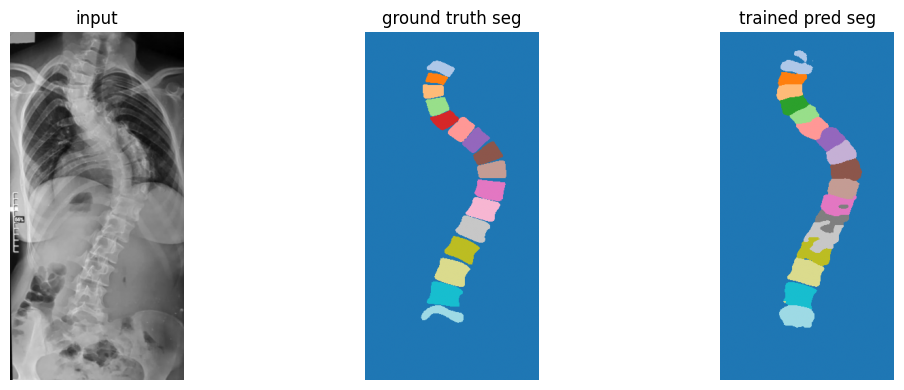

In [20]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
seg_pred = predict_one(model, case["image"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input"); axes[0].set_axis_off()
axes[1].imshow(case["seg"], cmap="tab20");             axes[1].set_title("ground truth seg"); axes[1].set_axis_off()
axes[2].imshow(seg_pred, cmap="tab20");                axes[2].set_title("trained pred seg"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()

### 6.5 · Cobb Pipeline Diagnostic

How much Cobb error comes from the model vs the `cobb_from_segmentation_tangent` geometry?
Feed **ground-truth masks** through the same angle extraction to measure the pipeline floor.

In [21]:
gt_cobb_rows = []
for _, row in VAL_DF.iterrows():
    gt_deg = row.get("cobb_angle_deg")
    if pd.isna(gt_deg):
        continue
    case = preprocess_case(row)
    gt_pred_deg = cobb_from_segmentation_tangent(case["seg"].numpy())
    if np.isfinite(gt_pred_deg):
        gt_cobb_rows.append({
            "cobb_true": float(gt_deg),
            "cobb_gt_pipe": float(gt_pred_deg),
            "abs_err": abs(gt_pred_deg - float(gt_deg)),
        })

gt_cobb_df = pd.DataFrame(gt_cobb_rows)
pipe_mae = gt_cobb_df["abs_err"].mean()
pipe_r = gt_cobb_df[["cobb_true", "cobb_gt_pipe"]].corr().iloc[0, 1]
model_mae = stats_tta.get("cobb_mae", float("nan"))

print(f"Cobb pipeline diagnostic — tangent method (n={len(gt_cobb_df)} val cases with GT):\n")
print(f"  {'source':<25s} {'MAE':>8s} {'r':>8s}")
print(f"  {'-'*25} {'-'*8} {'-'*8}")
print(f"  {'GT mask → tangent':<25s} {pipe_mae:7.2f}° {pipe_r:8.3f}")
print(f"  {'pred mask → tangent':<25s} {stats['cobb_mae']:7.2f}° {stats['cobb_r']:8.3f}")
print(f"  {'pred+TTA → tangent':<25s} {model_mae:7.2f}° {stats_tta['cobb_r']:8.3f}")
print(f"\n  Pipeline floor = {pipe_mae:.1f}° MAE even with perfect segmentation.")
print(f"  Model adds {model_mae - pipe_mae:.1f}° on top of pipeline error.")

Cobb pipeline diagnostic — tangent method (n=32 val cases with GT):

  source                         MAE        r
  ------------------------- -------- --------
  GT mask → tangent           14.06°    0.790
  pred mask → tangent         12.66°    0.794
  pred+TTA → tangent          13.08°    0.783

  Pipeline floor = 14.1° MAE even with perfect segmentation.
  Model adds -1.0° on top of pipeline error.


## 7 · 5-Fold Cross-Validation

Single 80/20 split on 249 cases (corrected) gives noisy metrics (30 val cases). 5-fold CV trains 5 models on different splits and reports mean ± std — much more reliable for comparing approaches.

In [22]:
from sklearn.model_selection import KFold

def train_fold(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    fold: int,
    num_epochs: int = NUM_EPOCHS,
    warmup: int = WARMUP_EPOCHS,
    patience: int = PATIENCE,
) -> tuple[nn.Module, float, list[dict]]:
    cfg = build_run_config({"phase": "cv", "fold": int(fold), "n_folds": int(N_FOLDS) if 'N_FOLDS' in globals() else None})
    _cached = find_cached_run(cfg)
    if _cached is not None:
        state, hist_df, _metrics = load_run(_cached)
        m = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=False, dropout=DROPOUT, encoder_name=ENCODER_NAME).to(DEVICE)
        m.load_state_dict(state)
        return m, float(_metrics["best_val_dice"]), hist_df.to_dict('records')

    torch.manual_seed(SEED + fold)

    m = EncoderUNet(in_ch=1, num_classes=NUM_SEG_CLASSES, pretrained=True, dropout=DROPOUT, encoder_name=ENCODER_NAME).to(DEVICE)
    tl = DataLoader(SpineDataset(train_df, augment=True, augment_fn=augment_v4), batch_size=BATCH_SIZE, shuffle=True)
    vl = DataLoader(SpineDataset(val_df, augment=False), batch_size=BATCH_SIZE, shuffle=False)

    for p in m.encoder_params():
        p.requires_grad = False
    opt = torch.optim.Adam(m.decoder_params(), lr=LR_DECODER, weight_decay=WEIGHT_DECAY)
    sched = None

    best_dice, best_st, no_imp = -1.0, None, 0
    hist = []

    for ep in range(1, num_epochs + 1):
        if ep == warmup + 1:
            for p in m.encoder_params():
                p.requires_grad = True
            opt = torch.optim.Adam([
                {"params": m.encoder_params(), "lr": LR_ENCODER},
                {"params": m.decoder_params(), "lr": LR_DECODER},
            ], weight_decay=WEIGHT_DECAY)
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs - warmup)

        tl_arr = run_epoch(m, tl, opt)
        vs = validate(m, vl)
        if sched is not None:
            sched.step()

        hist.append({"epoch": ep, "train_loss": float(tl_arr.mean()), "val_loss": vs["loss"], "val_dice": vs["dice"]})

        if vs["dice"] > best_dice:
            best_dice = vs["dice"]
            best_st = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if ep > warmup and no_imp >= patience:
            break

    m.load_state_dict(best_st)
    save_run(new_run_dir(cfg), m, pd.DataFrame(hist), cfg,
             {"best_val_dice": best_dice, "stopped_epoch": int(hist[-1]['epoch'])})
    return m, best_dice, hist


In [23]:
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results = []
cv_histories = []
t_cv_start = time.time()

for fold, (train_idx, val_idx) in enumerate(kf.split(TRAINABLE), 1):
    fold_train = TRAINABLE.iloc[train_idx].reset_index(drop=True)
    fold_val   = TRAINABLE.iloc[val_idx].reset_index(drop=True)
    print(f"\n{'='*60}")
    print(f"Fold {fold}/{N_FOLDS}  train={len(fold_train)}  val={len(fold_val)}")
    print(f"{'='*60}")

    t_fold = time.time()
    fold_model, fold_best_dice, fold_hist = train_fold(fold_train, fold_val, fold)
    cv_histories.append(fold_hist)

    fold_eval = evaluate_set(fold_model, fold_val, tta=True)
    fold_stats = summarize(fold_eval)
    fold_stats["fold"] = fold
    fold_stats["best_val_dice"] = fold_best_dice
    fold_stats["stopped_epoch"] = fold_hist[-1]["epoch"]
    cv_results.append(fold_stats)

    elapsed = time.time() - t_fold
    print(f"  fold {fold} done in {elapsed:.0f}s  "
          f"best_dice={fold_best_dice:.3f}  eval_dice(TTA)={fold_stats['dice']:.3f}  "
          f"stopped@ep{fold_stats['stopped_epoch']}")

    del fold_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

cv_df = pd.DataFrame(cv_results)
print(f"\ntotal CV time: {time.time() - t_cv_start:.0f}s")
print(f"\n{'='*60}")
print(f"5-Fold Cross-Validation Summary (with TTA)")
print(f"{'='*60}")
for col in ["dice", "iou", "hd95_px", "cobb_mae", "cobb_r", "sev_acc", "sev_kappa", "best_val_dice", "stopped_epoch"]:
    if col not in cv_df.columns:
        continue
    vals = cv_df[col].dropna()
    if len(vals) == 0:
        continue
    print(f"  {col:16s}  {vals.mean():.3f} ± {vals.std():.3f}   (range {vals.min():.3f}–{vals.max():.3f})")

print(f"\nPer-fold breakdown:")
print(cv_df[["fold", "dice", "iou", "hd95_px", "cobb_mae", "best_val_dice", "stopped_epoch"]].to_string(index=False))


Fold 1/5  train=199  val=50


KeyboardInterrupt: 

## 8 · Summary

Retrained the same ResNet-34 + U-Net recipe on the **corrected v2** dataset.
Compare per-fold dice / iou / hd95 / cobb_mae against the v3 baseline (152
trainable cases) to quantify the impact of the colleague's mask corrections.
